In [ ]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from scipy.optimize import root

s = Simulation()
N_t = 500
tg = 1000
tlist = np.linspace(0, tg, N_t)

# compute cos params
cos_amp, cos_wd = compute_cos_params(s, tg)
heff_params = s.heff(cos_wd, cos_amp)
Delta = heff_params[2][2] - heff_params[0][0]
# rrr follows from the heff response to amplitude, as both Omega_ab and Omega_bc are linear rrr is constant for all amp- and wd values
rrr = heff_params[1][2] / heff_params[0][1] # compute the RabiRateRatio (RRR) from the two rabirates in cos dirve case

In [41]:
# with a given gate time we compute the fidelity for cos drive and drag drive
def compute_htarget(tg, use_drag=True):
    ht, ht_args = h_target(Delta, rrr, tg, use_drag = use_drag)
    return ht, ht_args
ht, args = compute_htarget(tg)

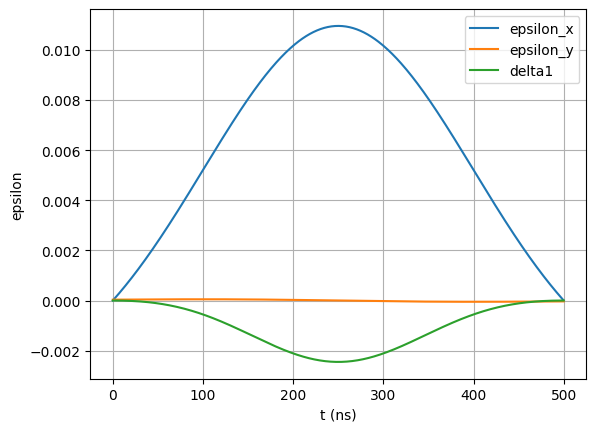

In [42]:
ex = np.array([args[0](t) for t in tlist])
ey = np.array([args[1](t) for t in tlist])
d1 = np.array([args[2](t) for t in tlist])
plt.figure()
plt.plot(tlist, ex, label='epsilon_x')
plt.plot(tlist, ey, label='epsilon_y')
plt.plot(tlist, d1, label='delta1')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

To check gate fidelity with target hamiltonian, we sweep tg and compute Delta and rrr accordingly


Also we use a normal effective hamiltonian for cos drive to compensate compare

100%|██████████| 20/20 [00:01<00:00, 19.28it/s]


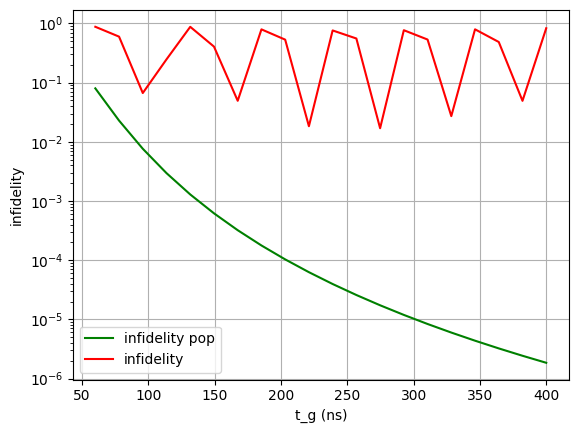

In [43]:
def plot_tg_fid_curve(hamiltonian_function, n, tg_min = 60, tg_max = 400):
    lf_pop = []
    lf = []
    ltg = np.linspace(tg_min, tg_max, n)
    for tg in tqdm(ltg):
        h, _ = hamiltonian_function(tg)
        tlist = np.linspace(0, tg, N_t)
        f = extract_fidelity(h, tlist)
        fpop = extract_pop_fid(h, tlist)['iswap_fidelity']
        lf_pop.append(1-fpop)
        lf.append(1-f)
    ax = plt.subplot()
    plt.plot(ltg, lf_pop, label='infidelity pop', color='green')
    plt.plot(ltg, lf, label='infidelity', color='red')
    plt.xlabel('t_g (ns)')
    plt.ylabel('infidelity')
    ax.set_yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_tg_fid_curve(compute_htarget, 20)

After verifying the fidelity of the target-hamiltonian, now the target hamiltonian must be achieved by a given time-dependant pulse-shape that is applied to the coupler

In [44]:
import pickle
from pathlib import Path
ROOT = Path.cwd()

# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
wd_range = [0.7 * 2*np.pi, 0.712 * 2*np.pi]
amp_real_range = (0, 0.6 * 2*np.pi)
amp_imag_range = (0, 0.1 * 2*np.pi)

# Load coefficients if they exist
if coeff_file.exists():
    with open(coeff_file, 'rb') as f:
        coefficients_data = pickle.load(f)
    coeffs01 = coefficients_data['coeffs01']
    coeffs00 = coefficients_data['coeffs00']
    coeffs11 = coefficients_data['coeffs11']
    coeffs12 = coefficients_data['coeffs12']
    coeffs22 = coefficients_data['coeffs22']
    coeffs02 = coefficients_data['coeffs02']
    print(f"Coefficients loaded from {coeff_file}")
else:
    N = 20
    coeffs01 = fit_heff_element(s, 0, 1, wd_range, amp_real_range, amp_imag_range, N,N,N)
    coeffs00 = fit_heff_element(s, 0, 0, wd_range, amp_real_range, amp_imag_range, N,N,N)
    coeffs11 = fit_heff_element(s, 1, 1, wd_range, amp_real_range, amp_imag_range, N,N,N)
    coeffs12 = fit_heff_element(s, 1, 2, wd_range, amp_real_range, amp_imag_range, N,N,N)
    coeffs22 = fit_heff_element(s, 2, 2, wd_range, amp_real_range, amp_imag_range, N,N,N)
    coeffs02 = fit_heff_element(s, 0, 2, wd_range, amp_real_range, amp_imag_range, N,N,N)
    # Save coefficients
    coefficients_data = {
        'coeffs01': coeffs01,
        'coeffs00': coeffs00,
        'coeffs11': coeffs11,
        'coeffs12': coeffs12,
        'coeffs22': coeffs22,
        'coeffs02': coeffs02
    }
    with open(coeff_file, 'wb') as f:
        pickle.dump(coefficients_data, f)
        print(f"Coefficients saved to {coeff_file}")


Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


setup the functions that are used to optimize the 3 independent parameters wd, amp_r and amp_i for achieving max compliance with the target hamiltonian. 

In [45]:
from scipy.optimize import root
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = np.array([1, wd, ar, ai, wd**2, ar**2, ai**2,
                  wd*ar, wd*ai, ar*ai])
    return x @ coeffs
    
from scipy.optimize import least_squares

def find_parameter_change_fit(wd0, heff_t):
    def residuals(x):
        dw, ar, ai = x
        wd = wd0 + dw
        amp = ar + 1j*ai

        deltadiff = (heff_fit(coeffs00, wd, amp) - heff_fit(coeffs11, wd, amp)) - (heff_t[0,0] - heff_t[1,1])
        deltadiff2 = (heff_fit(coeffs11, wd, amp) - heff_fit(coeffs22, wd, amp)) - (heff_t[1,1] - heff_t[2,2])
        omega_diff = heff_fit(coeffs01, wd, amp) - heff_t[0,1]
        omega2_diff = heff_fit(coeffs12, wd, amp) - heff_t[1,2]
        omega3_diff = heff_fit(coeffs02, wd, amp) - heff_t[0,2]

        weights = np.array([1,1,1,1])

        return weights*np.array([
            abs(deltadiff)**2-np.real(deltadiff2),
            abs(omega_diff)**2,
            abs(omega2_diff)**2,
            abs(omega3_diff)**2
        ])
    dwd_range = (-1,1)
    da_range = amp_real_range
    res = least_squares(
        residuals,
        x0=[0,0,0],
        bounds=([dwd_range[0], da_range[0], da_range[0]],
                [dwd_range[1], da_range[1], da_range[1]])
    )
    return {"dw": res.x[0], "dar": res.x[1], "dai": res.x[2]}

from scipy.optimize import minimize
def find_parameters_error(wd0, heff_t):
    lambda_leak = 1
    def objective(x):
        dw, ar, ai = x
        wd = wd0 + dw
        amp = ar + 1j*ai

        deltadiff = (
            heff_fit(coeffs00, wd, amp)
            - heff_fit(coeffs11, wd, amp)
        ) - (heff_t[0,0] - heff_t[1,1])

        deltadiff2 = (
            heff_fit(coeffs11, wd, amp)
            - heff_fit(coeffs22, wd, amp)
        ) - (heff_t[1,1] - heff_t[2,2])

        omega_diff = heff_fit(coeffs01, wd, amp) - heff_t[0,1]
        omega2_diff = heff_fit(coeffs12, wd, amp) - heff_t[1,2]
        omega3_diff = heff_fit(coeffs02, wd, amp) - heff_t[0,2]

        return (
            abs(deltadiff) * 2
            + abs(omega_diff)
            + abs(omega2_diff)
            + abs(omega3_diff)
            - lambda_leak * np.real(deltadiff2)
        )
    res = minimize(
        objective,
        x0=[0, 0, 0],
        bounds=[(-1,1),amp_real_range,amp_imag_range],method="L-BFGS-B")
    result = {"dw": res.x[0],"dar": res.x[1],"dai": res.x[2]}
    return result

# define a function to change the list representation of h_target to one time dependant matrix function
def sum_list(ht):
    def f(t):
        result = ht[0]
        for i in range(1, len(ht)):
            result = result + ht[i][0] * ht[i][1](t)
        return result
    return f

setup the heff_modulated method and test hamiltonian compliance with one example

In [46]:
ht, _ = compute_htarget(tg)
ht_func = sum_list(ht)
wd0 = s.find_resonance(0)
def heff_modulated(t, args=None, dw = None, da = None):
    if not dw or not da: 
        res = find_parameter_change_fit(wd0, ht_func(t))
        dw = res['dw']
        da = res['dar'] + 1j*res['dai']
    return Qobj(s.heff(wd0 + dw.real, da))
    
# for some examples, show if the hamiltonian comes close to the target
tt = 350
print("h0: ")
print("heff_modulated: ")
h_mod = heff_modulated(tt)
for i in range(0,2):
    h_mod[i][i] -= h_mod[0][0]
display(h_mod)
print("htarget: ")
display(sum_list(ht)(tt))

h0: 
heff_modulated: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.00000000e+00+0.00000000e+00j  2.54641665e-12-1.07780175e-12j
  -2.61740326e-22+2.69927228e-22j]
 [ 2.54641665e-12+1.07780175e-12j  1.10986775e-11+0.00000000e+00j
   2.55164909e-11-1.08001644e-11j]
 [-2.61740326e-22-2.69927228e-22j  2.55164909e-11+1.08001644e-11j
  -1.17369658e+00+0.00000000e+00j]]

htarget: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.        +0.00000000e+00j  0.00402358+2.19493022e-05j
   0.        +0.00000000e+00j]
 [ 0.00402358-2.19493022e-05j -0.00132357+0.00000000e+00j
   0.04029262+2.19802874e-04j]
 [ 0.        +0.00000000e+00j  0.04029262-2.19802874e-04j
  -1.17501201+0.00000000e+00j]]

drive_signal_func gives the time dependant DRAG amplitude 

mesolve cannot deal with the difficult heff_modulated / pulse_shape_modulated functions as a parameter, so instead we precompute values and then simply interpolate between the defined values.

In [47]:
import pickle

force_computation = True
heff_file = coeff_dir / 'precomputed_heff_modulated.pkl'
drive_freq_precomputed = []
drive_amp_real_precomputed = []
drive_amp_imag_precomputed = []

if heff_file.exists() and not force_computation:
    with open(heff_file, 'rb') as f:
        heff_data = pickle.load(f)
    print(f"heff_modulated loaded from {heff_file}")
    drive_freq_precomputed = heff_data['frequency']
    drive_amp_real_precomputed = heff_data['amplitude_real']
    drive_amp_imag_precomputed = heff_data['amplitude_imag']
else:
    for t in tqdm(tlist):
        res = find_parameter_change_fit(wd0, ht_func(t))
        freq= wd0 + res['dw']
        amp_real = res['dar']
        amp_imag = res['dai']
        drive_freq_precomputed.append(freq)
        drive_amp_real_precomputed.append(amp_real)
        drive_amp_imag_precomputed.append(amp_imag)
    
    drive_freq_precomputed = np.array(drive_freq_precomputed)
    drive_amp_real_precomputed = np.array(drive_amp_real_precomputed)
    drive_amp_imag_precomputed = np.array(drive_amp_imag_precomputed)
    heff_data = {
        'frequency': drive_freq_precomputed,
        'amplitude_real': drive_amp_real_precomputed,
        'amplitude_imag': drive_amp_imag_precomputed
    }
    with open(heff_file, 'wb') as f:
        pickle.dump(heff_data, f)
    print(f"heff_modulated, frequency and amplitudes saved to {heff_file}")

100%|██████████| 500/500 [00:02<00:00, 171.04it/s]

heff_modulated, frequency and amplitudes saved to /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/precomputed_heff_modulated.pkl


In [48]:
def drive_wd_interp(t, args=None):
    if t <= tlist[0]:
        return drive_freq_precomputed[0]
    if t >= tlist[-1]:
        return drive_freq_precomputed[-1]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    return (1 - alpha) * drive_freq_precomputed[idx] + alpha * drive_freq_precomputed[idx + 1]

def drive_amp_interp(t, args=None):
    if t <= tlist[0]:
        return drive_amp_real_precomputed[0] + 1j*drive_amp_imag_precomputed[0]
    if t >= tlist[-1]:
        return drive_amp_real_precomputed[-1] + 1j*drive_amp_imag_precomputed[-1]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    amp_real = (1 - alpha) * drive_amp_real_precomputed[idx] + alpha * drive_amp_real_precomputed[idx + 1]
    amp_imag = (1 - alpha) * drive_amp_imag_precomputed[idx] + alpha * drive_amp_imag_precomputed[idx + 1]
    return amp_real + 1j*amp_imag

def drive_signal_interp(t, args=None):
    return drive_amp_interp(t) * np.cos(drive_wd_interp(t) * t)

def heff_mod_build(t, args=None):
    wd = drive_wd_interp(t)
    a = drive_amp_interp(t)
    return Qobj(s.heff(wd, a))

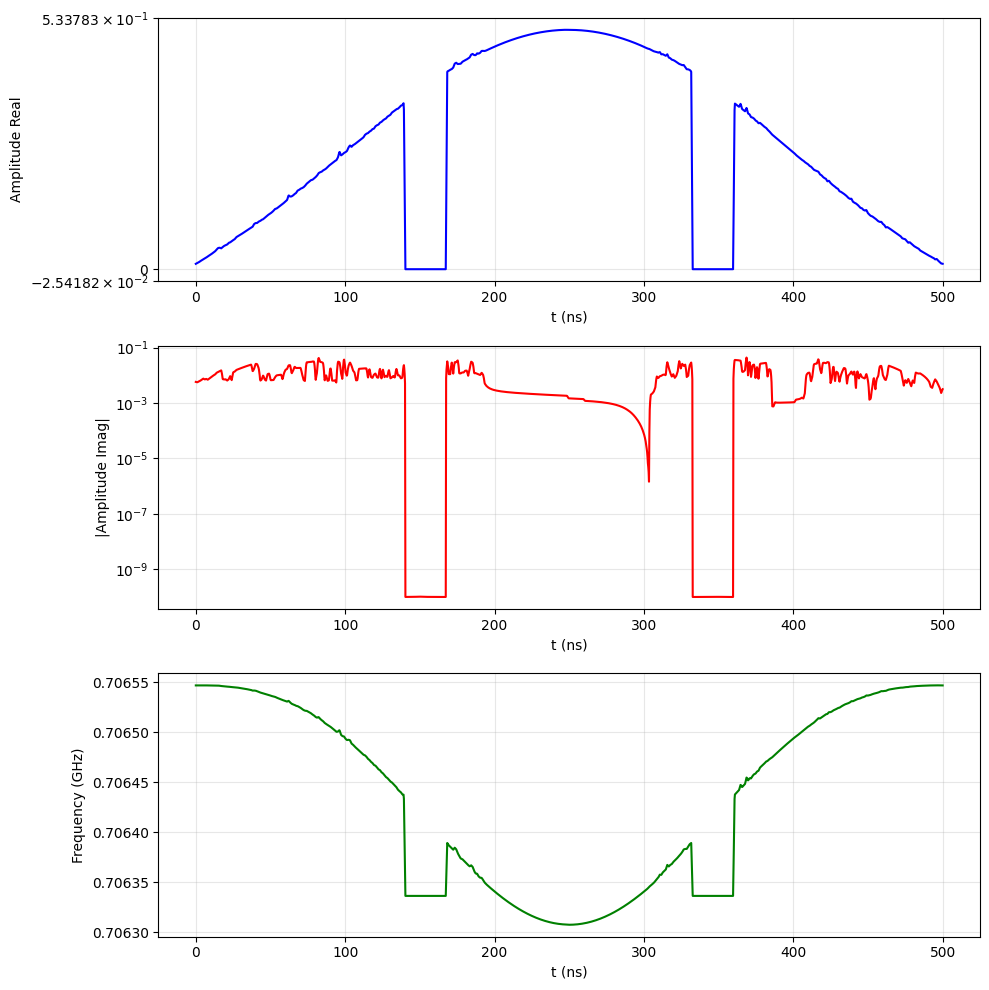

In [49]:
def plot_drive_components(t_end=tg, n=2000):
    t_vals = np.linspace(0, t_end, n)
    amp_real = np.array([drive_amp_interp(t).real for t in t_vals])
    amp_imag = np.array([drive_amp_interp(t).imag for t in t_vals])
    freq = np.array([drive_wd_interp(t) for t in t_vals])
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    
    axes[0].plot(t_vals, amp_real, 'b-', linewidth=1.5)
    axes[0].set_yscale('symlog')
    axes[0].set_xlabel('t (ns)')
    axes[0].set_ylabel('Amplitude Real')
    axes[0].grid(True, which='both', alpha=0.3)
    
    axes[1].plot(t_vals, np.abs(amp_imag), 'r-', linewidth=1.5)
    axes[1].set_yscale('log')
    axes[1].set_xlabel('t (ns)')
    axes[1].set_ylabel('|Amplitude Imag|')
    axes[1].grid(True, which='both', alpha=0.3)
    
    axes[2].plot(t_vals, freq/(2*np.pi), 'g-', linewidth=1.5)
    # axes[2].set_yscale('log')
    axes[2].set_xlabel('t (ns)')
    axes[2].set_ylabel('Frequency (GHz)')
    axes[2].grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
plot_drive_components()

with the heff_modulated_interp function, the extraction of fidelity measurements can be done fast. To test for the right adoption of h_target, we compare fidelities for h_t, h_modulated and the raw hamiltonian with the given drive signal (h_drive). In the following those 3 cases will correspond to the values fid_engineered, fid_modulated, fid_drive.

In [50]:
# precompute heff_mod:
heff_precomputed = [heff_mod_build(t) for t in tqdm(tlist)]

def heff_modulated_interp(t):
    if t <= tlist[0]:
        return heff_precomputed[0]
    if t >= tlist[-1]:
        return heff_precomputed[-1]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    return (1 - alpha) * heff_precomputed[idx] + alpha * heff_precomputed[idx + 1]

100%|██████████| 500/500 [00:37<00:00, 13.50it/s]


In [51]:
# engineered
tlist_fid = np.linspace(0, tg, 2300)
f_e = extract_fidelity(ht, tlist_fid)
fpop_e = extract_pop_fid(ht, tlist_fid, plot=False)['iswap_fidelity']
print(f"infidelity gauss drag: {(1-f_e):.2e} pop: {(1-fpop_e):.2e}")
# compare to an effective hamiltonian without drag
ht_nodrag, args = compute_htarget(tg, use_drag=False)
f_e_nodrag = extract_fidelity(ht_nodrag, tlist_fid)
fpop_e_nodrag = extract_pop_fid(ht_nodrag, tlist_fid, plot=False)['iswap_fidelity']
print(f"infidelity gauss no drag: {(1-f_e_nodrag):.2e} pop: {(1-fpop_e_nodrag):.2e}")
# verify that drag improves the engineered outcome
h_cos = [s.H0_dressed, [s.V1_dressed, lambda t, args: cos_amp * np.cos(cos_wd * t)]]
f_e_nodrag = extract_fidelity(h_cos, tlist_fid, sim = s)
fpop_e_nodrag = extract_pop_fid(h_cos, tlist_fid, sim=s, plot=False)['iswap_fidelity']
print(f"infidelity cos drive direct: {(1-f_e_nodrag):.2e} pop: {(1-fpop_e_nodrag):.2e}")

infidelity gauss drag: 7.67e-02 pop: 4.87e-07
infidelity gauss no drag: 1.79e-01 pop: 4.07e-02
infidelity cos drive direct: 7.54e-01 pop: 8.94e-02


  0%|          | 0/2299 [00:00<?, ?it/s]

  0%|          | 0/2299 [00:00<?, ?it/s]

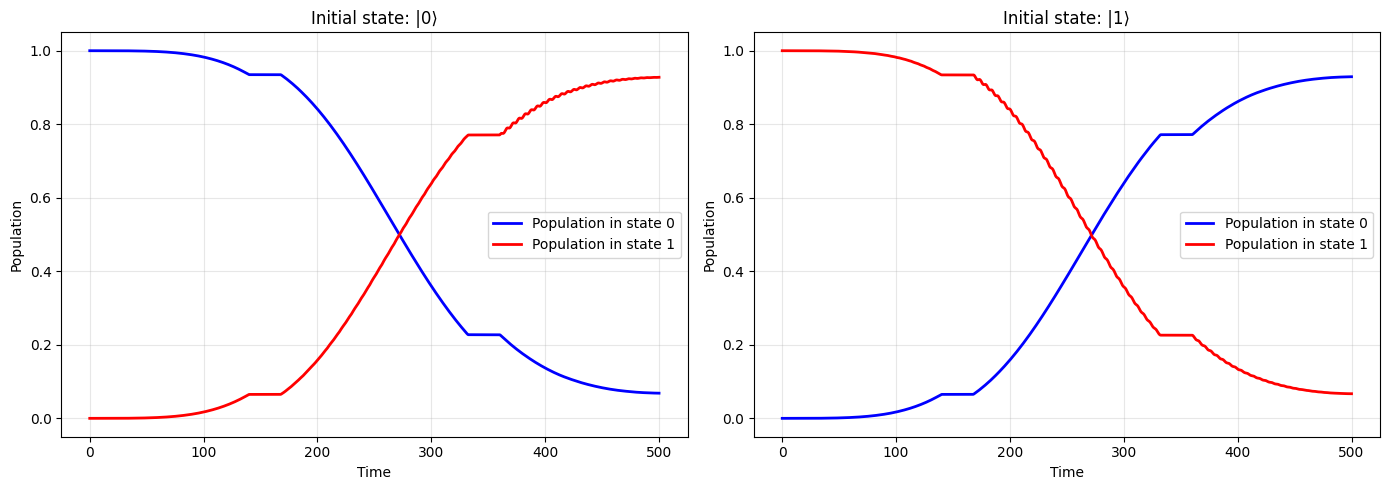

infidelity modulated pop: 7.15e-02


In [52]:
# modulated
# f_m = extract_fidelity(heff_modulated_interp, tlist_fid, debug=True ,plot=False)
fpop_m = extract_pop_fid(heff_modulated_interp, tlist_fid, debug=True,plot=True)['iswap_fidelity']
print(f"infidelity modulated pop: {(1-fpop_m):.2e}")


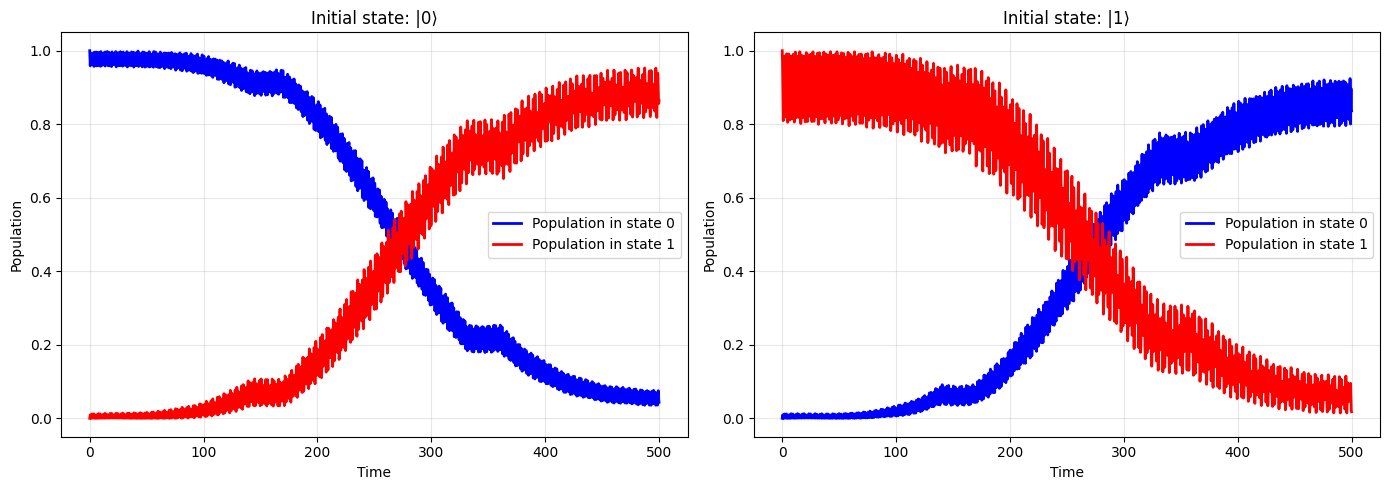

infidelity driven: 6.79e-01 pop: 1.50e-01


In [53]:
# simulate the result directly over H0 and V1 from s 
lh = [s.H0_dressed, [s.V1_dressed, drive_signal_interp]]
f_d = extract_fidelity(lh, tlist_fid, sim=s)
fpop_d = extract_pop_fid(lh, tlist_fid, sim=s, plot=True)['iswap_fidelity']
print(f"infidelity driven: {(1-f_d):.2e} pop: {(1-fpop_d):.2e}")